###The model forecasts EV charging demand at a station using operational, temporal, traffic, pricing, and environmental factors. This can help charging station operators anticipate demand, optimize charger utilization, reduce waiting times, and improve energy management.

###Importing necessary libraries


In [138]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

##Mounting google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Setting paths for the project

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/EV Demand Forecasting"
RAW_PATH = PROJECT_PATH + "/data/raw"
PROCESSED_PATH = PROJECT_PATH + "/data/processed"

In [ ]:
import os
os.makedirs(PROCESSED_PATH, exist_ok=True)

Loading the dataset

In [ ]:
df = pd.read_csv(RAW_PATH + "/ev_charging_dataset.csv")

###EDA and Feature Engineering


In [ ]:
df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,99.865576,30.528616,7,261.673850,4,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,100.000000,41.504507,50,49.916518,3,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,95.733464,45.016306,50,54.019568,8,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,100.000000,28.291670,11,155.773370,3,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,100.000000,55.810835,11,306.369479,5,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [ ]:
df.shape

(8354, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [ ]:
df.isnull().sum()

,0
timestamp,0
station_id,0
location_type,0
vehicle_id,0
vehicle_type,0
arrival_time,0
charging_start_time,0
charging_end_time,0
waiting_time,0
battery_capacity_kWh,0


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["arrival_time"] = pd.to_datetime(df["arrival_time"])
df["charging_start_time"] = pd.to_datetime(df["charging_start_time"])
df["charging_end_time"] = pd.to_datetime(df["charging_end_time"])

In [ ]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

Charging Session Features

These features capture charging behavior and battery usage characteristics.

- soc_used: Change in battery state of charge during charging.
- battery_utilization: Fraction of battery capacity utilized.
- energy_per_hour: Charging rate per hour.

In [ ]:
df["soc_used"] = df["final_soc"] - df["initial_soc"]

In [ ]:
df["battery_utilization"] = df["energy_consumed_kWh"] / df["battery_capacity_kWh"]

In [ ]:
df["energy_per_hour"] = df["energy_consumed_kWh"] / df["charging_duration"]


Operational Features

These features describe station utilization, queue conditions, charging efficiency, and energy pricing.

- waiting_per_queue
- load_per_queue
- price_per_kWh
- charging_efficiency

In [ ]:
df["waiting_per_queue"] = df["waiting_time"] / (df["queue_length"] + 1)


In [ ]:
df["load_per_queue"] = df["station_load"] / (df["queue_length"] + 1)

In [ ]:
df["price_per_kWh"] = df["electricity_price"] / df["energy_consumed_kWh"]


In [ ]:
df["charging_efficiency"] = df["charging_power_kW"] / df["battery_capacity_kWh"]

In [ ]:
df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward,year,month,day,hour,minute,is_weekend,soc_used,battery_utilization,energy_per_hour,waiting_per_queue,load_per_queue,price_per_kWh,charging_efficiency
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,99.865576,30.528616,7,261.673850,4,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299,2025,1,1,0,0,0,50.881026,0.508810,0.116667,2.400000,3.032334,0.447449,0.116667
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,100.000000,41.504507,50,49.916518,3,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644,2025,1,1,0,15,0,41.504507,0.415045,0.831478,2.000000,5.249305,0.131793,0.500000
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,95.733464,45.016306,50,54.019568,8,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846,2025,1,1,0,30,0,60.021742,0.600217,0.833333,1.222222,3.511795,0.211035,0.666667
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,100.000000,28.291670,11,155.773370,3,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018,2025,1,1,0,45,0,70.729175,0.707292,0.181621,2.250000,5.450762,0.219853,0.275000
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,100.000000,55.810835,11,306.369479,5,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466,2025,1,1,1,0,0,74.414446,0.744144,0.182168,1.333333,2.604378,0.240455,0.146667


Session Timing Features

These features represent the duration and timing characteristics of charging sessions.

- charging_delay
- total_session_time
- charging_completion

In [ ]:
df["charging_delay"] = (df["charging_start_time"] - df["arrival_time"]).dt.total_seconds() / 60

In [ ]:
df["total_session_time"] = (df["charging_end_time"] - df["arrival_time"]).dt.total_seconds() / 60

In [ ]:
df["charging_completion"] = (df["final_soc"] / 100) * df["battery_capacity_kWh"]

In [ ]:
df.drop(columns=["timestamp","arrival_time","charging_start_time","charging_end_time","vehicle_id","assigned_charger_id"], inplace=True)

Some engineered features were removed because they directly contain information about the target variable or are generated after the charging session has completed. Retaining such features could introduce data leakage and result in unrealistic model performance.

In [ ]:
df.shape


(8354, 37)

In [ ]:
df.head()

,station_id,location_type,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,charging_priority,optimization_reward,year,month,day,hour,minute,is_weekend,soc_used,battery_utilization,energy_per_hour,waiting_per_queue,load_per_queue,price_per_kWh,charging_efficiency,charging_delay,total_session_time,charging_completion
0,ST004,Urban,Two-Wheeler,12,60,48.984550,99.865576,30.528616,7,261.673850,4,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,Low,-8.622299,2025,1,1,0,0,0,50.881026,0.508810,0.116667,2.400000,3.032334,0.447449,0.116667,12.0,273.0,59.919346
1,ST005,Urban,Two-Wheeler,8,100,58.495493,100.000000,41.504507,50,49.916518,3,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,Low,-1.935644,2025,1,1,0,15,0,41.504507,0.415045,0.831478,2.000000,5.249305,0.131793,0.500000,8.0,57.0,100.000000
2,ST019,Highway,Car,11,75,35.711722,95.733464,45.016306,50,54.019568,8,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,Low,-18.201846,2025,1,1,0,30,0,60.021742,0.600217,0.833333,1.222222,3.511795,0.211035,0.666667,11.0,65.0,71.800098
3,ST008,Urban,Two-Wheeler,9,40,29.270825,100.000000,28.291670,11,155.773370,3,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,Medium,-7.404018,2025,1,1,0,45,0,70.729175,0.707292,0.181621,2.250000,5.450762,0.219853,0.275000,9.0,164.0,40.000000
4,ST008,Highway,Two-Wheeler,8,75,25.585554,100.000000,55.810835,11,306.369479,5,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,Low,-6.577466,2025,1,1,1,0,0,74.414446,0.744144,0.182168,1.333333,2.604378,0.240455,0.146667,8.0,314.0,75.000000


In [ ]:
df.dtypes

,0
station_id,object
location_type,object
vehicle_type,object
waiting_time,int64
battery_capacity_kWh,int64
initial_soc,float64
final_soc,float64
energy_consumed_kWh,float64
charging_power_kW,int64
charging_duration,float64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
waiting_time,8354.0,9.526335,4.894049,0.000000,6.000000,9.000000,13.000000,28.000000
battery_capacity_kWh,8354.0,61.079722,25.001163,30.000000,40.000000,60.000000,75.000000,100.000000
initial_soc,8354.0,34.808452,14.478839,10.000582,22.371986,34.638994,47.310647,59.992462
final_soc,8354.0,98.495545,3.258039,65.079759,98.463666,99.998223,100.000000,100.000000
energy_consumed_kWh,8354.0,39.079746,18.973883,7.502195,23.675251,35.148384,51.363447,89.929089
charging_power_kW,8354.0,22.449126,16.813449,7.000000,11.000000,11.000000,22.000000,50.000000
charging_duration,8354.0,178.700376,149.120567,10.000000,64.118008,133.700252,247.946169,776.551110
queue_length,8354.0,4.591573,2.828987,0.000000,3.000000,5.000000,7.000000,15.000000
station_load,8354.0,53.177399,27.380740,10.053024,28.029710,49.421293,77.600445,100.000000
electricity_price,8354.0,9.959945,2.878798,5.000000,7.510000,9.955000,12.397500,15.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

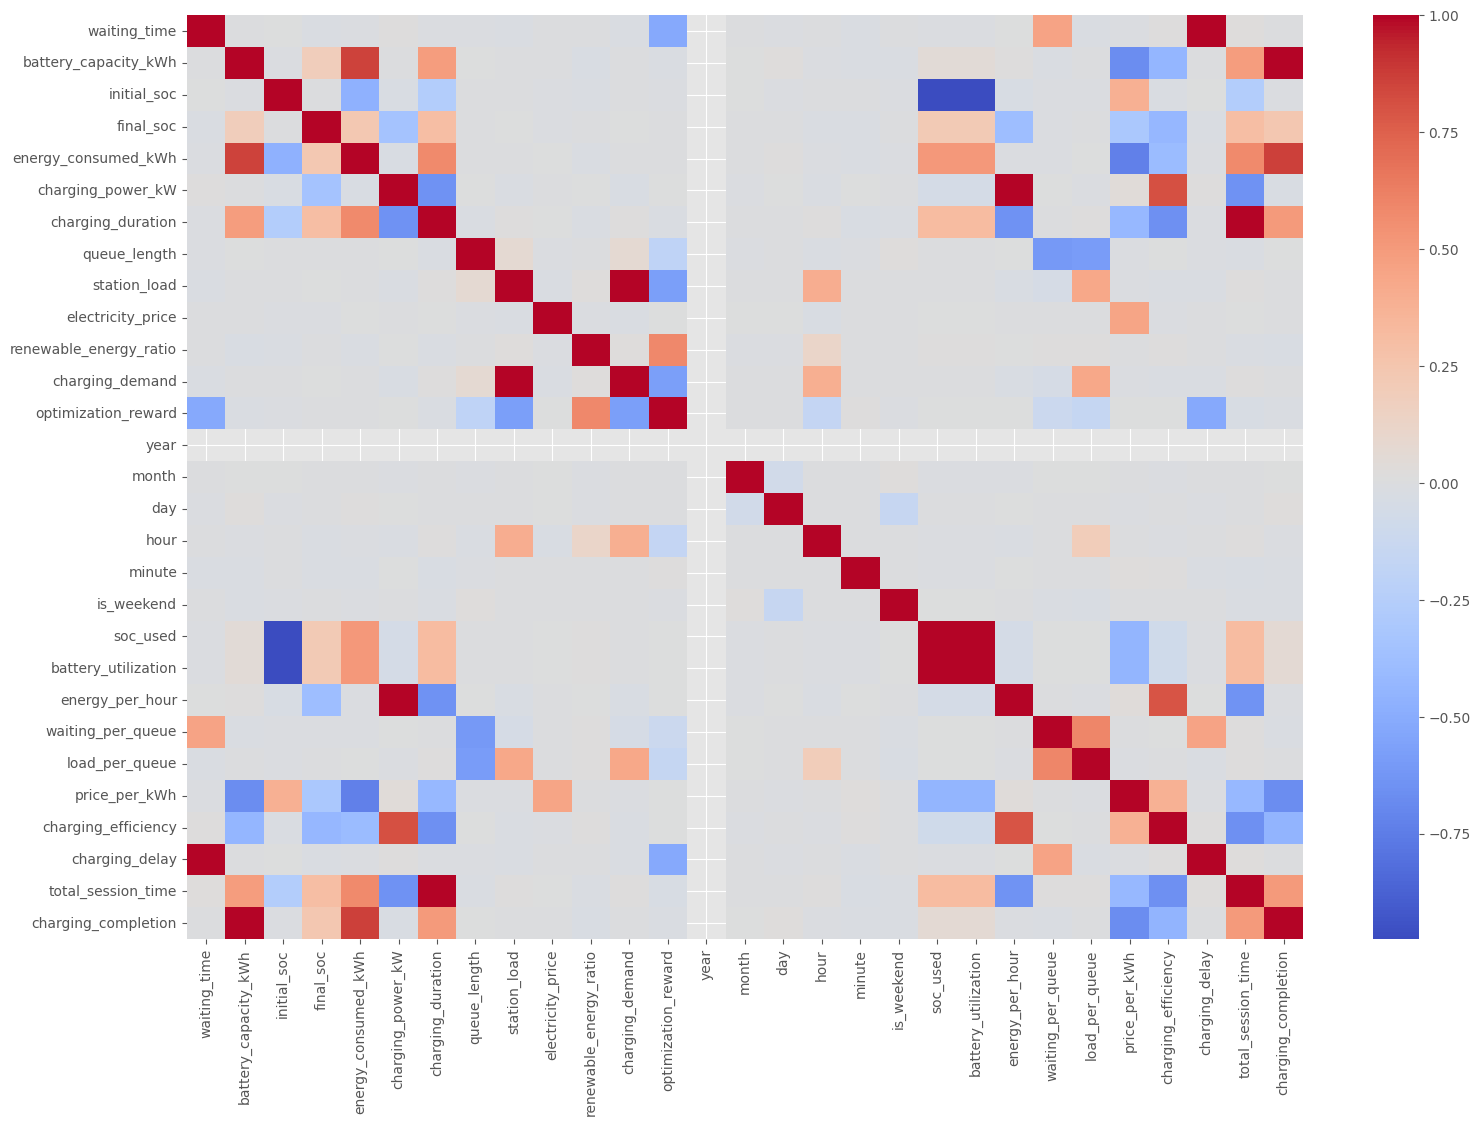

In [ ]:
plt.figure(figsize=(18,12))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.show()

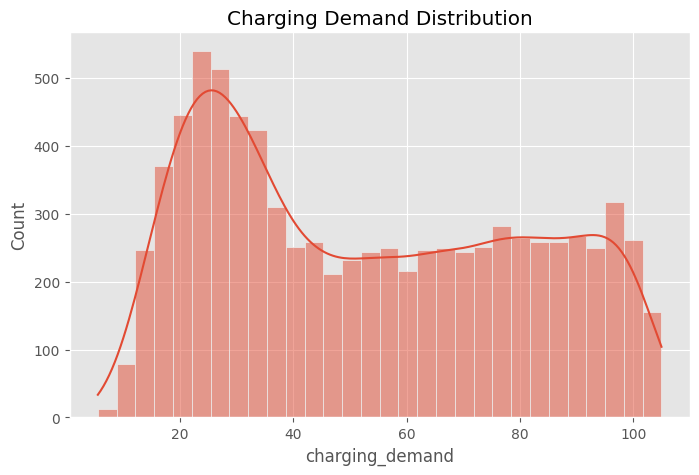

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["charging_demand"], bins=30, kde=True)
plt.title("Charging Demand Distribution")
plt.show()

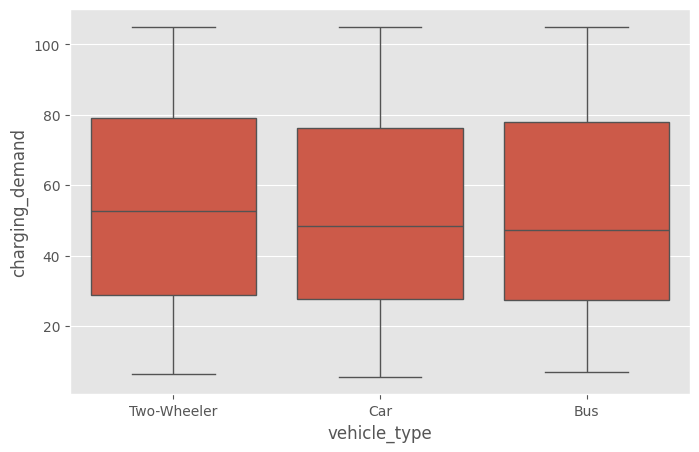

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="vehicle_type", y="charging_demand", data=df)
plt.show()

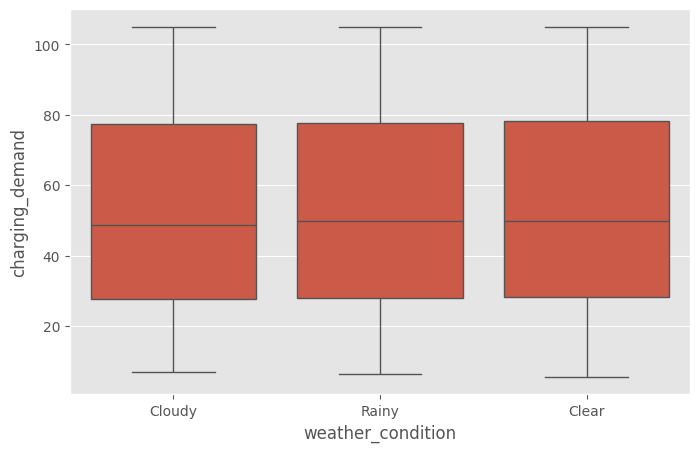

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="weather_condition", y="charging_demand", data=df)
plt.show()

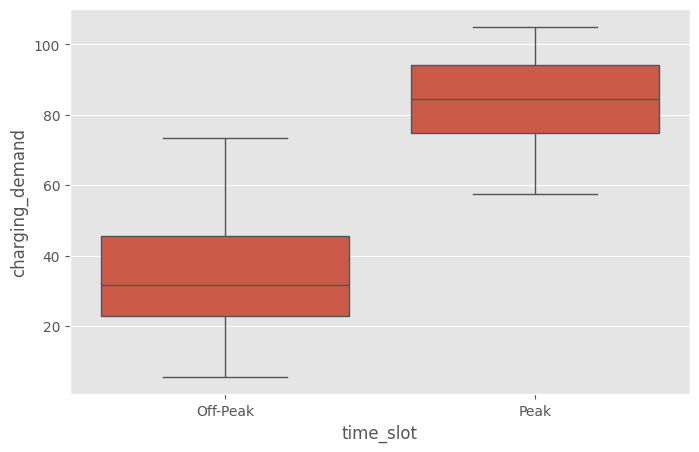

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="time_slot", y="charging_demand", data=df)
plt.show()

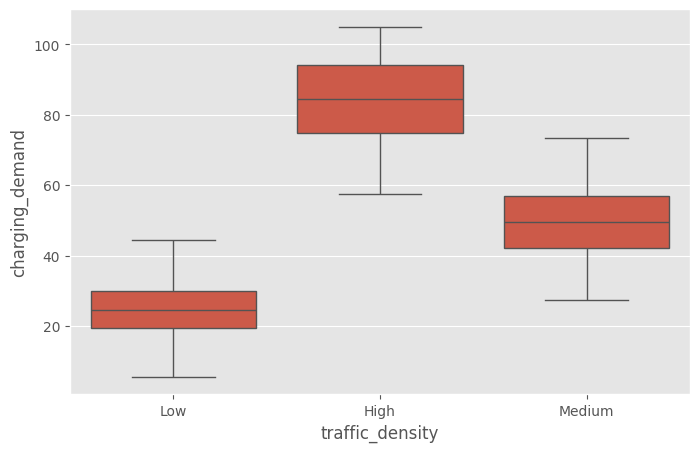

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="traffic_density", y="charging_demand", data=df)
plt.show()

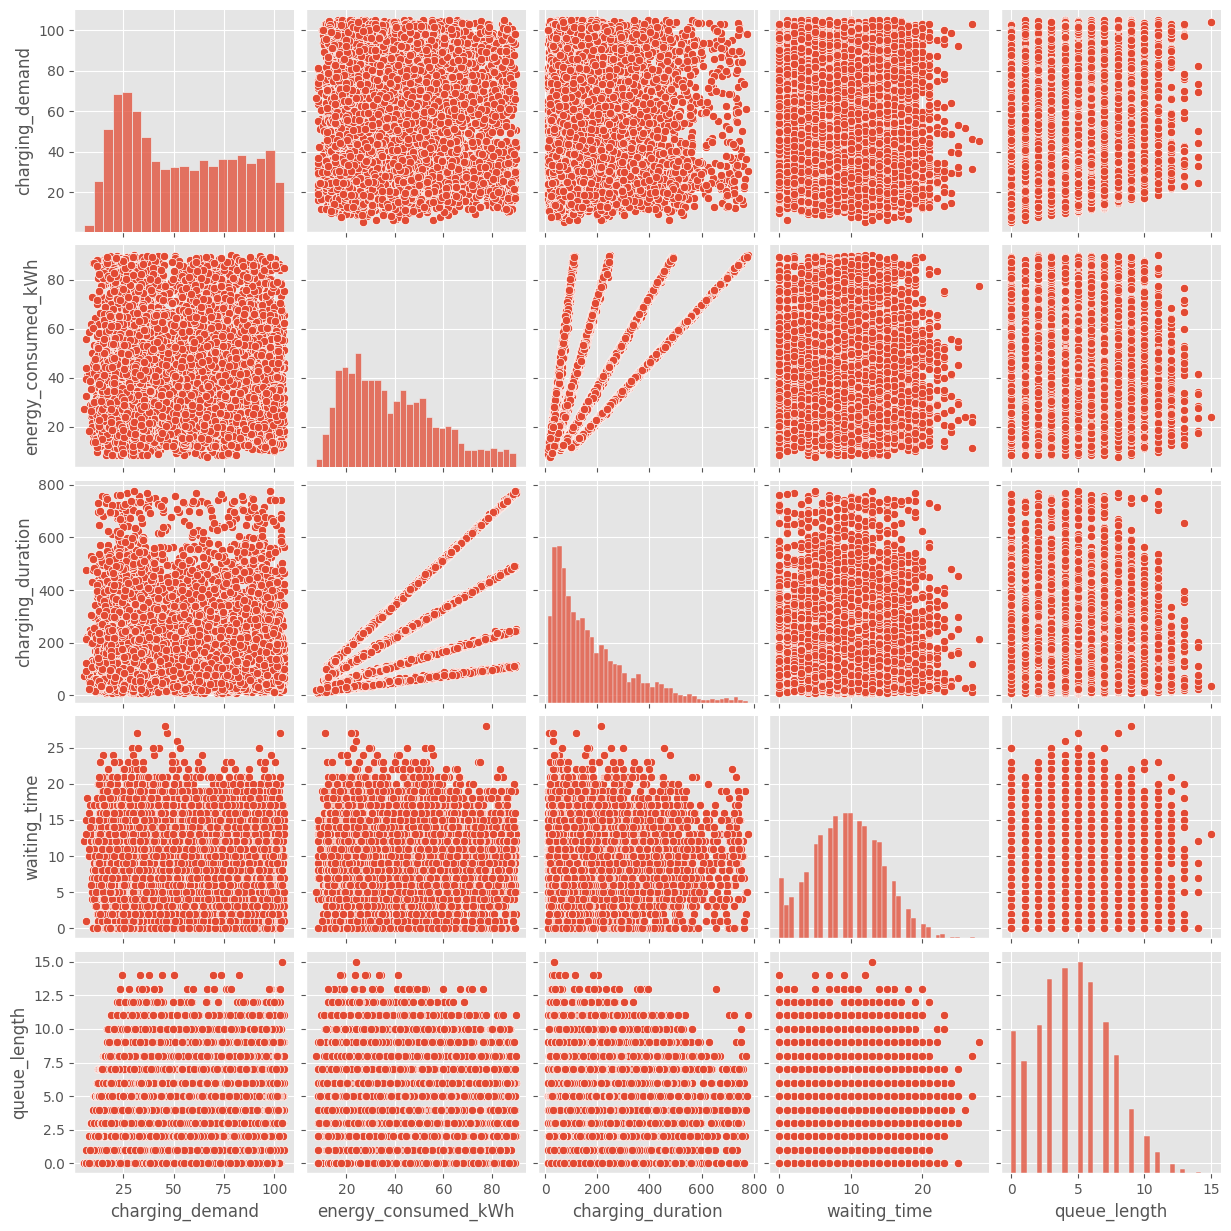

In [ ]:
sns.pairplot(df[["charging_demand","energy_consumed_kWh","charging_duration","waiting_time","queue_length"]])
plt.show()

In [ ]:
df.drop(columns=["soc_used","battery_utilization","energy_per_hour","charging_completion","optimization_reward"], inplace=True)

In [ ]:
df.drop(columns=["final_soc","energy_consumed_kWh","charging_duration","charging_delay","total_session_time"], inplace=True)

Some engineered features were created for experimentation and analysis. However, features that introduced target leakage were later removed before model training.

In [ ]:
df.head()

,station_id,location_type,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,charging_power_kW,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,charging_priority,year,month,day,hour,minute,is_weekend,waiting_per_queue,load_per_queue,price_per_kWh,charging_efficiency
0,ST004,Urban,Two-Wheeler,12,60,48.984550,7,4,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,Low,2025,1,1,0,0,0,2.400000,3.032334,0.447449,0.116667
1,ST005,Urban,Two-Wheeler,8,100,58.495493,50,3,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,Low,2025,1,1,0,15,0,2.000000,5.249305,0.131793,0.500000
2,ST019,Highway,Car,11,75,35.711722,50,8,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,Low,2025,1,1,0,30,0,1.222222,3.511795,0.211035,0.666667
3,ST008,Urban,Two-Wheeler,9,40,29.270825,11,3,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,Medium,2025,1,1,0,45,0,2.250000,5.450762,0.219853,0.275000
4,ST008,Highway,Two-Wheeler,8,75,25.585554,11,5,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,Low,2025,1,1,1,0,0,1.333333,2.604378,0.240455,0.146667


In [ ]:
df["year"].nunique()

1

In [ ]:
df.drop(columns=["year"], inplace=True)

In [ ]:
df["month"].value_counts()

,count
month,
1,2976
3,2690
2,2688


#Categorical Feature Encoding

Machine learning models require numerical input. Therefore, categorical features such as station ID, vehicle type, weather condition, day of week, and time slot are converted into numerical representations using one-hot encoding.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.shape

(8354, 53)

Advanced Interaction Features

Additional interaction features are created to capture complex relationships between charging station utilization, renewable energy availability, waiting time, and charging power.

- effective_station_load
- power_to_wait_ratio
- renewable_load

In [ ]:
df["effective_station_load"] = df["station_load"] * df["queue_length"]

In [ ]:
df["power_to_wait_ratio"] = df["charging_power_kW"] / (df["waiting_time"] + 1)

In [ ]:
df["renewable_load"] = df["renewable_energy_ratio"] * df["station_load"]

In [ ]:
X = df.drop("charging_demand", axis=1)
y = df["charging_demand"]

The target variable is charging_demand. All remaining columns are used as input features for model training.

In [ ]:
df.to_csv(PROCESSED_PATH + "/final_ev_dataset.csv", index=False)

In [ ]:
df.drop(columns=["station_load","effective_station_load","renewable_load"], inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.shape

(8354, 53)

In [ ]:
df.head()

,waiting_time,battery_capacity_kWh,initial_soc,charging_power_kW,queue_length,electricity_price,renewable_energy_ratio,charging_demand,month,day,hour,minute,is_weekend,waiting_per_queue,load_per_queue,price_per_kWh,charging_efficiency,station_id_ST002,station_id_ST003,station_id_ST004,station_id_ST005,station_id_ST006,station_id_ST007,station_id_ST008,station_id_ST009,station_id_ST010,station_id_ST011,station_id_ST012,station_id_ST013,station_id_ST014,station_id_ST015,station_id_ST016,station_id_ST017,station_id_ST018,station_id_ST019,station_id_ST020,location_type_Urban,vehicle_type_Car,vehicle_type_Two-Wheeler,traffic_density_Low,traffic_density_Medium,weather_condition_Cloudy,weather_condition_Rainy,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,time_slot_Peak,charging_priority_Low,charging_priority_Medium,power_to_wait_ratio
0,12,60,48.984550,7,4,13.66,0.280335,17.242398,1,1,0,0,0,2.400000,3.032334,0.447449,0.116667,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0.538462
1,8,100,58.495493,50,3,5.47,0.392127,18.324933,1,1,0,15,0,2.000000,5.249305,0.131793,0.500000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1,0,1,0,5.555556
2,11,75,35.711722,50,8,9.50,0.103979,36.028168,1,1,0,30,0,1.222222,3.511795,0.211035,0.666667,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,4.166667
3,9,40,29.270825,11,3,6.22,0.248553,17.146935,1,1,0,45,0,2.250000,5.450762,0.219853,0.275000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1.100000
4,8,75,25.585554,11,5,13.42,0.234926,14.577768,1,1,1,0,0,1.333333,2.604378,0.240455,0.146667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0,1,0,1.222222


In [ ]:
df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})

In [ ]:
df.dtypes

,0
waiting_time,int64
battery_capacity_kWh,int64
initial_soc,float64
charging_power_kW,int64
queue_length,int64
electricity_price,float64
renewable_energy_ratio,float64
charging_demand,float64
month,int32
day,int32


In [ ]:
X = df.drop("charging_demand", axis=1)
y = df["charging_demand"]

The dataset is split into training and testing sets using an 80:20 ratio. The training set is used for model learning, while the testing set is used to evaluate model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)

(6683, 52)


In [ ]:
print(X_test.shape)

(1671, 52)


In [ ]:
print(y_train.shape)

(6683,)


In [ ]:
print(y_test.shape)

(1671,)


**Model Training and Evaluation**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Baseline Model - Linear Regression

A Linear Regression model is trained as a baseline model to establish a reference point for performance comparison.

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 7.4155
MSE : 81.2751
RMSE: 9.0153
R²  : 0.895


Correlation analysis is performed to identify highly influential features and detect potential leakage or redundant variables.

In [ ]:
corr = df.corr(numeric_only=True)["charging_demand"].sort_values(ascending=False)
print(corr)

charging_demand             1.000000
time_slot_Peak              0.869288
load_per_queue              0.431760
hour                        0.397288
queue_length                0.069824
vehicle_type_Two-Wheeler    0.035330
station_id_ST012            0.024377
renewable_energy_ratio      0.020613
station_id_ST003            0.016748
station_id_ST007            0.013709
station_id_ST004            0.010971
station_id_ST002            0.010277
charging_priority_Low       0.008789
is_weekend                  0.003973
day_of_week_Sunday          0.003872
station_id_ST013            0.002232
day_of_week_Tuesday         0.001502
day_of_week_Saturday        0.001279
charging_priority_Medium    0.001278
weather_condition_Rainy     0.001029
day_of_week_Monday          0.000672
station_id_ST010            0.000575
station_id_ST014           -0.000081
month                      -0.000260
minute                     -0.000292
station_id_ST008           -0.000820
station_id_ST005           -0.001808
s

# Model Comparison

Multiple machine learning algorithms are trained and evaluated to identify the best-performing model for EV charging demand prediction.

Models Evaluated:
- Linear Regression
- Decision Tree
- Random Forest
- XGBoost
- CatBoost

In [ ]:
!pip install xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [ ]:
results = []

def evaluate_model(model, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": model_name,"MAE": mae,"MSE": mse,"RMSE": rmse,"R2 Score": r2})

In [ ]:
evaluate_model(LinearRegression(), "Linear Regression")

evaluate_model(DecisionTreeRegressor(random_state=42),"Decision Tree")

evaluate_model(RandomForestRegressor(random_state=42),"Random Forest")

evaluate_model(XGBRegressor(random_state=42),"XGBoost")

evaluate_model(CatBoostRegressor(verbose=0, random_state=42),"CatBoost")

###Comparing Models

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values("R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,2.614303,9.676961,3.110781,0.987497
4,CatBoost,2.637343,9.726228,3.118690,0.987434
3,XGBoost,2.781620,10.962321,3.310940,0.985837
1,Decision Tree,3.536841,19.177167,4.379174,0.975223
0,Linear Regression,7.415542,81.275144,9.015273,0.894992


#Hyperparameter Tuning

RandomizedSearchCV is used to search for optimal hyperparameter combinations for the Random Forest model.

In [137]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {"n_estimators": [100, 200, 300],"max_depth": [10, 20, 30, None],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4],"max_features": ["sqrt", "log2"]}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(rf,param_grid,n_iter=20,cv=5,scoring="r2",random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [139]:
best_rf = random_search.best_estimator_

In [140]:
y_pred = best_rf.predict(X_test)

In [141]:
print("R2 :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 : 0.9236468737143902
MAE: 6.180941138237024
RMSE: 7.687415547612194


In [142]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [143]:
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [144]:
y_pred = best_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 2.6143025135567775
MSE : 9.676961165920703
RMSE: 3.1107814397544393
R2  : 0.9874972626833932


Although hyperparameter optimization was performed, the tuned Random Forest model produced lower performance than the default Random Forest model. Therefore, the default Random Forest configuration was selected as the final model.

In [145]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": best_model.feature_importances_}).sort_values("Importance", ascending=False)

importance.head(15)

,Feature,Importance
48,time_slot_Peak,0.756171
6,renewable_energy_ratio,0.067018
13,load_per_queue,0.065330
4,queue_length,0.045649
38,traffic_density_Low,0.033008
39,traffic_density_Medium,0.023340
2,initial_soc,0.000905
5,electricity_price,0.000857
8,day,0.000841
14,price_per_kWh,0.000832


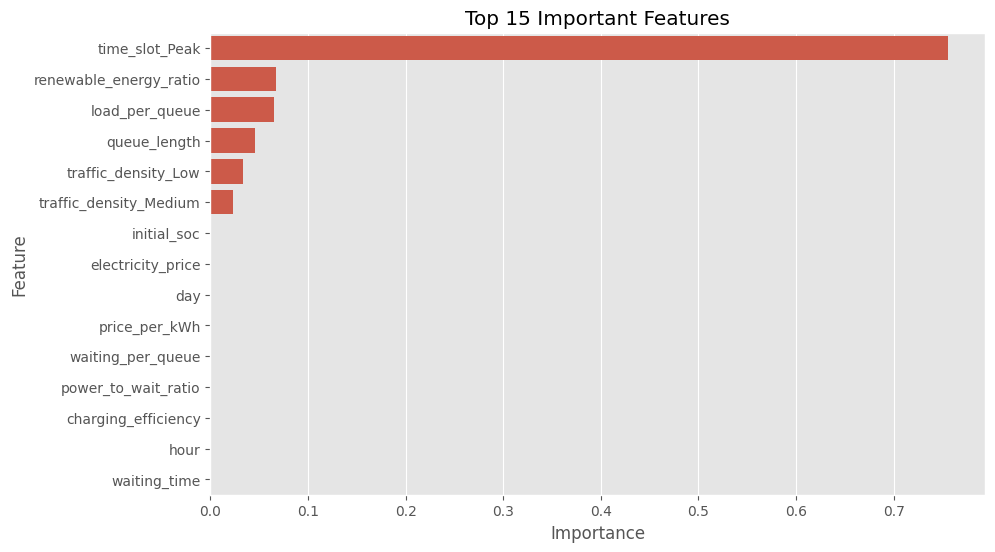

In [146]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features")
plt.show()

Feature importance scores are analyzed to understand which variables contribute most significantly to charging demand prediction.

#Overfitting Analysis

Training and testing performance are compared to evaluate model generalization and detect potential overfitting.

In [147]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R² :", train_r2)
print("Test R²  :", test_r2)

Train R² : 0.9980653429851207
Test R²  : 0.9874972626833932


#Cross Validation

K-Fold Cross Validation is performed to evaluate model stability across multiple data splits and assess robustness.

In [148]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:", scores)
print("Mean R²:", scores.mean())

Cross Validation R² Scores: [0.98662805 0.98699396 0.98621484 0.98584674 0.98700436]
Mean R²: 0.9865375899403647


# Model Persistence

The final trained model and feature list are saved using Joblib to enable deployment and future inference without retraining.

In [149]:
import joblib

joblib.dump(best_model, "random_forest_ev_model.pkl")

['random_forest_ev_model.pkl']

In [150]:
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']

In [151]:
df.to_csv("/content/drive/MyDrive/EV Demand Forecasting/data/processed/final_ev_dataset.csv", index=False)

In [156]:
import os

os.makedirs("/content/drive/MyDrive/EV Demand Forecasting/models", exist_ok=True)

In [157]:
import joblib

joblib.dump(best_model, "/content/drive/MyDrive/EV Demand Forecasting/models/random_forest_ev_model.pkl")

['/content/drive/MyDrive/EV Demand Forecasting/models/random_forest_ev_model.pkl']

In [158]:
joblib.dump(X.columns.tolist(), "/content/drive/MyDrive/EV Demand Forecasting/models/model_features.pkl")

['/content/drive/MyDrive/EV Demand Forecasting/models/model_features.pkl']

In [160]:
import os

os.makedirs("/content/drive/MyDrive/EV Demand Forecasting/outputs", exist_ok=True)

In [161]:
results_df.to_csv("/content/drive/MyDrive/EV Demand Forecasting/outputs/model_results.csv", index=False)

# Conclusion

An end-to-end machine learning pipeline was developed for EV Charging Demand Forecasting.

Key Achievements:
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Selection and Leakage Removal
- Model Training and Comparison
- Hyperparameter Tuning
- Feature Importance Analysis
- Overfitting Assessment
- Cross Validation
- Model Saving for Deployment

Among all evaluated models, Random Forest achieved the best performance with an R² score of approximately 0.9875.

The developed model can help EV charging station operators forecast charging demand and optimize charger utilization, energy allocation, and operational planning.